In [2]:
import math
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def calculate_bollinger_bands(data, window=10, num_of_std=2):
    """Calculate Bollinger Bands"""
    rolling_mean = data.rolling(window=window).mean()
    rolling_std = data.rolling(window=window).std()
    upper_band = rolling_mean + (rolling_std * num_of_std)
    lower_band = rolling_mean - (rolling_std * num_of_std)
    return upper_band, lower_band

def calculate_rsi(data, window=10):
    """Calculate Relative Strength Index"""
    delta = data.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window, min_periods=1).mean()
    avg_loss = loss.rolling(window=window, min_periods=1).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_roc(data, periods=10):
    """Calculate Rate of Change."""
    roc = ((data - data.shift(periods)) / data.shift(periods)) * 100
    return roc

In [4]:
tickers = [
    "AAPL", "AMZN", "META", "MSFT", "GOOG", "NVDA",
    "TSLA", "ORCL", "WMT", "JPM", "LLY", "NFLX",
    "MA", "XOM", "JNJ", "PLTR", "COST", "HD", "BAC",
    "AMD", "PG", "UNH", "GE", "CVX", "KO", "CSCO",
    "TMUS", "IBM", "AXP", "CRM", "MCD", "MU", "PEP"
]
ticker_data_frames = []

stats = {}
def get_data(tick):
    ticker = yf.Ticker(tick)
    data = ticker.history(period="730d", interval="1h")
    # data = ticker.history(period="365d", interval="1h")

    # We experiment with different amounts of data for
    # the training/prediction process.
    # So far, We get slightly better results with
    # lower dimensional data.
    ticker_df = pd.DataFrame({
        tick+"_open": data["Open"],
        tick+"_high": data["High"],
        tick+"_low": data["Low"],
        tick+"_close": data["Close"],
        # tick+"_volume": data["Volume"],
        # tick+"_upperBand": calculate_bollinger_bands(data["Close"])[0],
        # tick+"_lowerBand": calculate_bollinger_bands(data["Close"])[1],
        # tick+"_RSI": calculate_rsi(data["Close"]),
        # tick+"_ROC": calculate_roc(data["Close"]),
        # tick+"_PercentageChange": data["Close"].pct_change() * 100,
        # tick+"_Difference": data["Close"].diff()
    })

    MEAN = ticker_df.mean()
    STD = ticker_df.std()

    # Keep track of mean and std for denormalization later
    for col in MEAN.index:
        stats[f"{col}_mean"] = MEAN[col]
        stats[f"{col}_std"] = STD[col]

    # Normalize data
    ticker_df = (ticker_df - MEAN) / STD

    # Skip first 10 entries to account for Bollinger Bands window
    # ticker_data_frames.append(ticker_df[10:])

    # Simplified Data
    ticker_data_frames.append(ticker_df)

for label in tickers:
    get_data(label)

print(f"Number of dataframes: {len(ticker_data_frames)}")
print(f"Number of columns: {len(ticker_data_frames[0].columns)}")
print(f"Number of rows: {len(ticker_data_frames[0])}")
ticker_data_frames[0].tail()

Number of dataframes: 33
Number of columns: 4
Number of rows: 5082


,AAPL_open,AAPL_high,AAPL_low,AAPL_close
Datetime,,,,
2025-10-23 11:30:00-04:00,1.999417,2.011609,2.016086,2.018872
2025-10-23 12:30:00-04:00,2.020302,2.009368,2.030156,2.013088
2025-10-23 13:30:00-04:00,2.014840,2.005362,2.040145,2.016623
2025-10-23 14:30:00-04:00,2.017732,1.992383,2.033378,2.014373
2025-10-23 15:30:00-04:00,2.015804,1.993344,2.015976,2.004092


In [5]:
# Combine all ticker frames
df = pd.concat(ticker_data_frames, axis=1)

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove rows with NaN
df.dropna(inplace=True)

print(df.shape)
df.head()

(5075, 132)


,AAPL_open,AAPL_high,AAPL_low,AAPL_close,AMZN_open,AMZN_high,AMZN_low,AMZN_close,META_open,META_high,...,MCD_low,MCD_close,MU_open,MU_high,MU_low,MU_close,PEP_open,PEP_high,PEP_low,PEP_close
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-11-25 09:30:00-05:00,-1.570138,-1.569357,-1.592002,-1.567872,-1.674017,-1.673636,-1.679971,-1.670322,-1.838072,-1.835155,...,-0.760337,-0.678813,-1.140041,-1.136733,-1.138592,-1.133386,1.205485,1.206649,1.192314,1.215017
2022-11-25 10:30:00-05:00,-1.567670,-1.584740,-1.571700,-1.586327,-1.670174,-1.670746,-1.669428,-1.680295,-1.837088,-1.840986,...,-0.665520,-0.687462,-1.132804,-1.135396,-1.125367,-1.127496,1.212238,1.194980,1.213802,1.193833
2022-11-25 11:30:00-05:00,-1.585720,-1.584422,-1.576534,-1.575259,-1.679893,-1.681122,-1.673056,-1.671175,-1.838232,-1.842205,...,-0.658582,-0.673624,-1.130616,-1.138572,-1.127341,-1.135910,1.193513,1.175940,1.199068,1.190149
2022-11-28 09:30:00-05:00,-1.668296,-1.641143,-1.665802,-1.672927,-1.669043,-1.626311,-1.658772,-1.665965,-1.840838,-1.838813,...,-0.664364,-0.678813,-1.185483,-1.180869,-1.196237,-1.201711,1.221446,1.236898,1.223012,1.217472
2022-11-28 10:30:00-05:00,-1.672152,-1.675433,-1.667732,-1.673891,-1.665426,-1.661049,-1.663080,-1.659694,-1.848018,-1.851129,...,-0.704256,-0.726671,-1.201640,-1.208955,-1.208444,-1.217193,1.217763,1.205421,1.223012,1.224227


In [6]:
# But why tho??
labels = df.shift(-1)
labels = labels.iloc[:-1]
df = df.iloc[:-1]

# SEQUENCE_LENGTH = 13    # 2 days
SEQUENCE_LENGTH = 26    # 4 days
# SEQUENCE_LENGTH = 52    # 8 week

# Divide the time series data into "sequences" of data.
# Here, we divide the data into sequences of 2 days.
# Basically this is "tokenizing" the continuous data.
def create_sequences(data, labels, sequence_length):
    sequences = []
    label_sequences = []

    for i in range(len(data) - sequence_length - 1):
        sequences.append(data.iloc[i : i + sequence_length].values)
        label_sequences.append(labels.iloc[i+1 : i + sequence_length + 1])
    return np.array(sequences), np.array(label_sequences)

sequences, label_sequences = create_sequences(df, labels, SEQUENCE_LENGTH)
sequences.shape, label_sequences.shape

((5047, 26, 132), (5047, 26, 132))

In [7]:
# This probably isn't necessary, since the data loaders later
# on should be shuffling the data anyways.
# This was added before DataLoader was.
# We'll keep it since it shouldn't hurt anything.

# We shuffle the sequence tokens to eliminate bias
# coming from the ordering of the data. Remember:
# we encode the position into the vectors anyways,
# so this shuffle won't affect the embedding.

np.random.seed(0)

shuffled_indices = np.random.permutation(len(sequences))
sequences = sequences[shuffled_indices]
label_sequences = label_sequences[shuffled_indices]

training_size = int(len(sequences) * 0.8)
train_sequences = sequences[:training_size]
train_labels = label_sequences[:training_size]

# shuffled_indices = np.random.permutation(len(train_sequences))
# train_sequences = train_sequences[shuffled_indices]
# train_labels = train_labels[shuffled_indices]

other_sequences = sequences[training_size:]
other_labels = label_sequences[training_size:]

shuffled_indices = np.random.permutation(len(other_sequences))
other_sequences = other_sequences[shuffled_indices]
other_labels = other_labels[shuffled_indices]

validation_size = int(len(other_sequences) * 0.5)
validation_sequences = other_sequences[:validation_size]
validation_labels = other_labels[:validation_size]

test_sequences = other_sequences[validation_size:]
test_labels = other_labels[validation_size:]

# Transformer

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        # Ensure that the model dimension (d_model) is divisible by the number of heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        # Initialize dimensions
        self.d_model = d_model # Model's dimension
        self.num_heads = num_heads # Number of attention heads
        self.d_k = d_model // num_heads # Dimension of each head's key, query, and value

        # Linear layers for transforming inputs
        self.W_q = nn.Linear(d_model, d_model) # Query transformation
        self.W_k = nn.Linear(d_model, d_model) # Key transformation
        self.W_v = nn.Linear(d_model, d_model) # Value transformation
        self.W_o = nn.Linear(d_model, d_model) # Output transformation

    """
    TODO
    We can swap this out for a potentially more
    effective embedding method.
    """
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Calculate attention scores
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply mask if provided (useful for preventing attention to certain parts like padding)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        # Softmax is applied to obtain attention probabilities
        attn_probs = torch.softmax(attn_scores, dim=-1)

        # Multiply by values to obtain the final output
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        # Reshape the input to have num_heads for multi-head attention
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        # Combine the multiple heads back to original shape
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        # Apply linear transformations and split heads
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        # Perform scaled dot-product attention
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)

        # Combine heads and apply output transformation
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [9]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [10]:
"""
TODO
Experiment with different positional encodings.
    - Topological feature based encodings? Can represent related
      time series data better (i.e. related stocks/companies).
"""
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [11]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)  # Prevents overfitting

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [12]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

In [13]:
class Transformer(nn.Module):
    def __init__(self, input_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        # Use Linear layers instead of Embedding for continuous numerical input
        self.encoder_input_layer = nn.Linear(input_size, d_model)
        self.decoder_input_layer = nn.Linear(input_size, d_model)

        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        # The output layer should predict the next sequence of continuous values,
        # so it should have an output size equal to the input size.
        self.fc = nn.Linear(d_model, input_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, tgt):
        # Apply linear transformation and positional encoding
        src_embedded = self.dropout(self.positional_encoding(self.encoder_input_layer(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_input_layer(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            # Pass None for the mask as it's not used
            enc_output = enc_layer(enc_output, None)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            # Pass None for masks as they are not used
            dec_output = dec_layer(dec_output, enc_output, None, None)

        output = self.fc(dec_output)
        return output

# Setup & Training

In [14]:
# Convert numpy arrays to PyTorch tensors
# The data is continuous, so use float tensors instead of long tensors
src_data = torch.tensor(train_sequences).float().to(device)
tgt_data = torch.tensor(train_labels).float().to(device)

# The input size to the Transformer should be the number of features (columns)
input_size = train_sequences.shape[-1]

# Parameters
d_model = 512
num_heads = 8
num_layers = 6
d_ff = 2048
max_seq_length = SEQUENCE_LENGTH
dropout = 0.1
epoch_num = 50

# Initialize the Transformer with the correct input size
transformer = Transformer(input_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout).to(device)

In [15]:
# Use Mean Squared Error Loss for continuous output
criterion = nn.MSELoss()

# Optimizer for dyanmic adjustment of learning rate
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

train_loader = data.DataLoader(data.TensorDataset(src_data, tgt_data), batch_size=64, shuffle=True)

transformer.train()
for epoch in range(50):
    for x, y in train_loader: # Iterate over the training data loader
        optimizer.zero_grad()

        x = x.to(device).float()
        y = y.to(device).float()

        output = transformer(x, y[:, :-1, :])
        loss = criterion(output, y[:, 1:, :])

        loss.backward()
        optimizer.step()

    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 0.03460432216525078
Epoch: 2, Loss: 0.03299916163086891
Epoch: 3, Loss: 0.017255710437893867
Epoch: 4, Loss: 0.01671910472214222
Epoch: 5, Loss: 0.011751384474337101
Epoch: 6, Loss: 0.010399001650512218
Epoch: 7, Loss: 0.011479406617581844
Epoch: 8, Loss: 0.009510613046586514
Epoch: 9, Loss: 0.008331644348800182
Epoch: 10, Loss: 0.008501877076923847
Epoch: 11, Loss: 0.010296943597495556
Epoch: 12, Loss: 0.005710309371352196
Epoch: 13, Loss: 0.008475319482386112
Epoch: 14, Loss: 0.00548045476898551
Epoch: 15, Loss: 0.005937428679317236
Epoch: 16, Loss: 0.0050759101286530495
Epoch: 17, Loss: 0.005493836011737585
Epoch: 18, Loss: 0.0047862473875284195
Epoch: 19, Loss: 0.004389890003949404
Epoch: 20, Loss: 0.004960586782544851
Epoch: 21, Loss: 0.004457203671336174
Epoch: 22, Loss: 0.00526621425524354
Epoch: 23, Loss: 0.0034731777850538492
Epoch: 24, Loss: 0.004492043051868677
Epoch: 25, Loss: 0.005306981038302183
Epoch: 26, Loss: 0.0034403158351778984
Epoch: 27, Loss: 0.003

In [16]:
val_loader = data.DataLoader(data.TensorDataset(torch.tensor(validation_sequences).float().to(device), torch.tensor(validation_labels).float().to(device)), batch_size=64, shuffle=False)

transformer.eval()

with torch.no_grad():
    val_loss = 0.0
    for x, y in val_loader: # Iterate over the validation data loader
        x = x.to(device).float()
        y = y.to(device).float()

        # Adjust slicing for validation target data
        val_output = transformer(x, y[:, :-1, :])
        # Adjust the target for loss calculation
        val_loss += criterion(val_output, y[:, 1:, :]).item()

    # Calculate average validation loss
    val_loss /= len(val_loader)
    print(f"Validation Loss: {val_loss}")

Validation Loss: 0.0021130012755747885


In [17]:
def autoregressive_prediction(model, input_data, sequence_length):
    model.eval()

    predictions = []
    with torch.no_grad():
        # Initialize the decoder input with the last element of the source sequence
        decoder_input = input_data[:, -1:, :].to(device)

        for _ in range(sequence_length):
            # Use the transformer to predict the next step based on the decoder_input
            prediction = model(input_data, decoder_input)

            next_step_prediction = prediction[:, -1:, :] # Shape: (batch_size, 1, input_size)

            predictions.append(next_step_prediction.cpu().numpy())

            decoder_input = torch.cat((decoder_input, next_step_prediction), dim=1)

    return np.concatenate(predictions, axis=1)

def non_autoregressive_prediction(model, input_data):
    model.eval()

    with torch.no_grad():
        prediction = model(input_data, input_data)

    return prediction.cpu().numpy()


def denormalize_data(data, stats):
    denormalized_data = data.copy()
    for i, ticker in enumerate(tickers):
        for j, col in enumerate(df.columns):
            if col.startswith(ticker):
                mean = stats[f"{col}_mean"]
                std = stats[f"{col}_std"]
                denormalized_data[:, :, j] = denormalized_data[:, :, j] * std + mean
    return denormalized_data

def MSE(pred, actual):
    return np.mean((pred - actual) ** 2)

def MAE(pred, actual):
    return np.mean(np.abs(pred - actual))

MSE (Autoregressive): 0.0011087883112322996
MSE (Non-Autoregressive): 0.0010203736910704762
MAE (Autoregressive): 0.025721241027118293
MAE (Non-Autoregressive): 0.025984472052745462


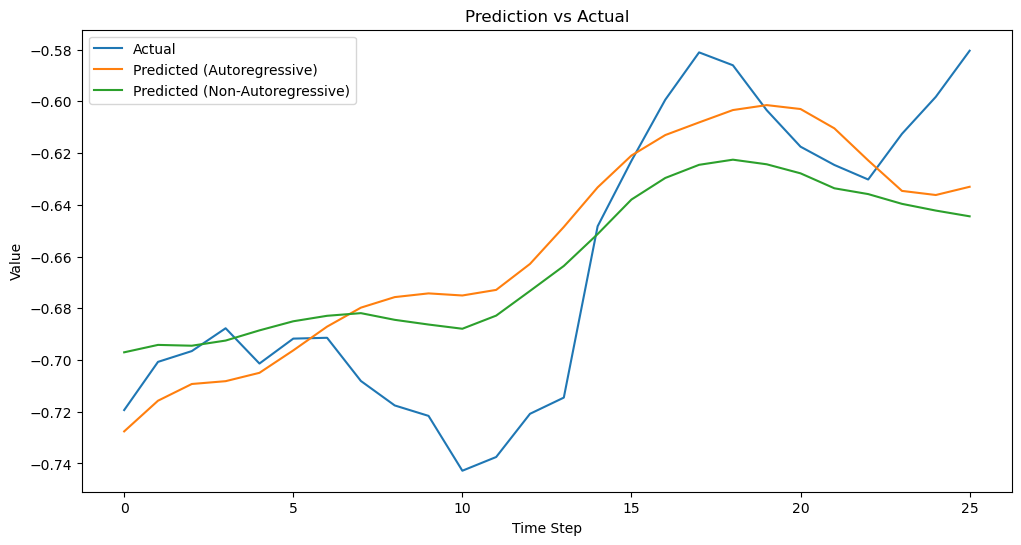

MSE (Autoregressive): 0.0012072659199514587
MSE (Non-Autoregressive): 0.0005858308687844571
MAE (Autoregressive): 0.03266883815598203
MAE (Non-Autoregressive): 0.020633636999901832


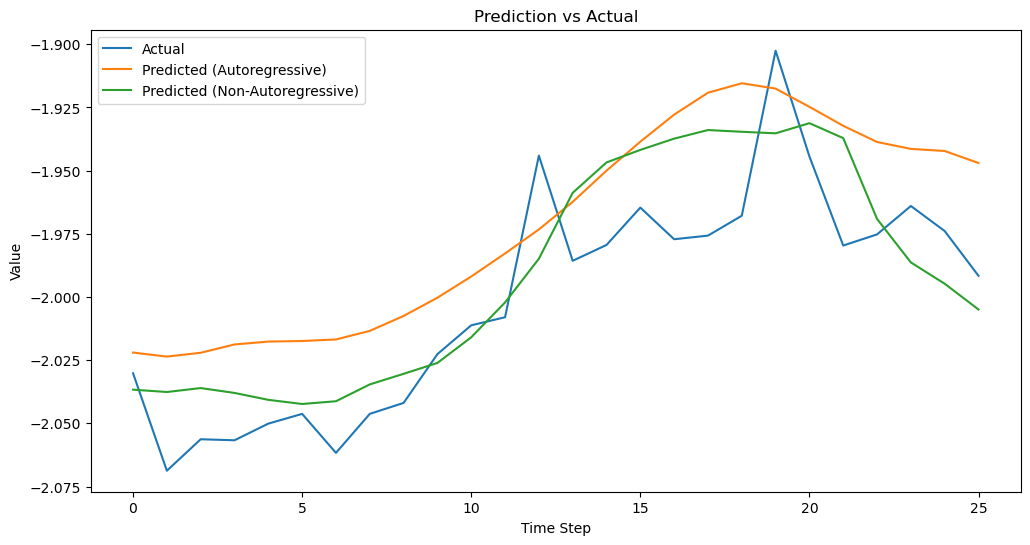

MSE (Autoregressive): 0.0007783741449255826
MSE (Non-Autoregressive): 0.0002629997474553223
MAE (Autoregressive): 0.021352005034192857
MAE (Non-Autoregressive): 0.012919083273382988


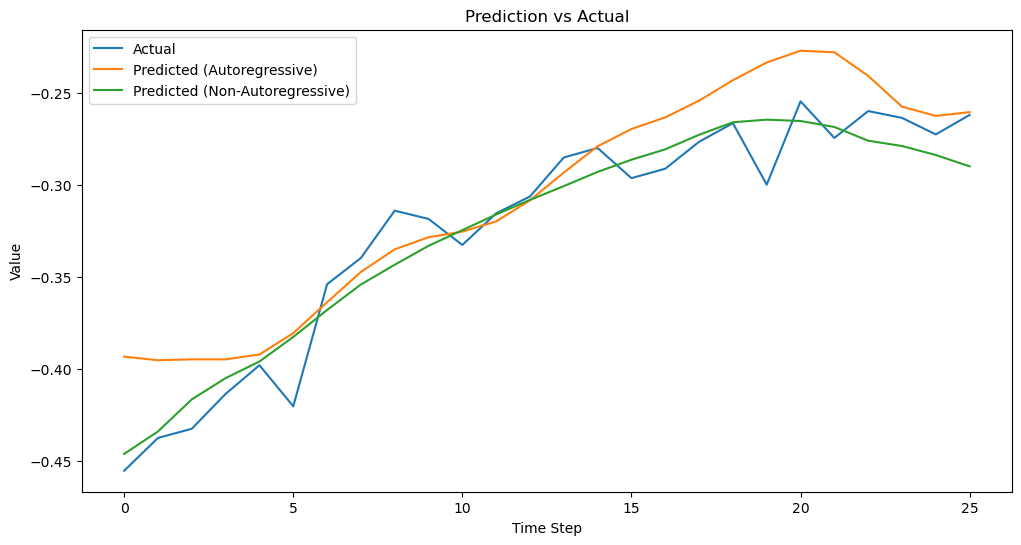

MSE (Autoregressive): 0.006749984289858542
MSE (Non-Autoregressive): 0.0034296035072536447
MAE (Autoregressive): 0.06916049622860079
MAE (Non-Autoregressive): 0.04992275255038771


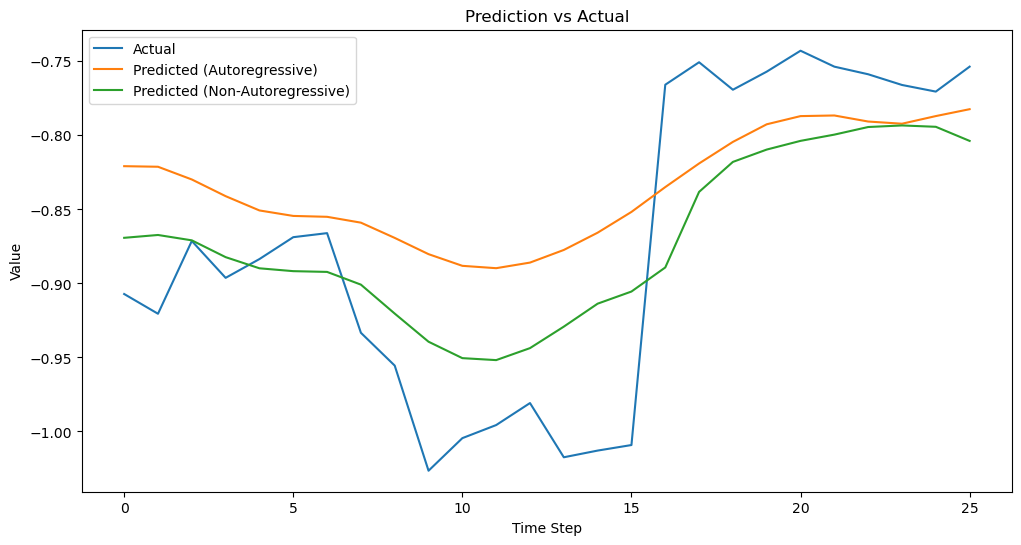

MSE (Autoregressive): 0.0028670908852619368
MSE (Non-Autoregressive): 0.0023284562596230796
MAE (Autoregressive): 0.04369967775015531
MAE (Non-Autoregressive): 0.036414156182869466


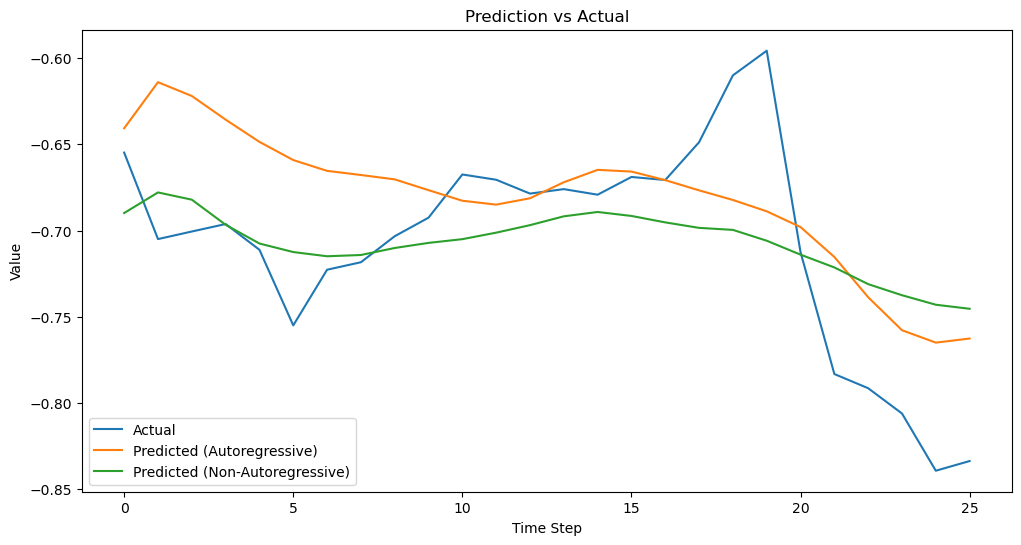

MSE (Autoregressive): 0.0014800574434816317
MSE (Non-Autoregressive): 0.0011405340376047948
MAE (Autoregressive): 0.029069093877706946
MAE (Non-Autoregressive): 0.025796310149965647


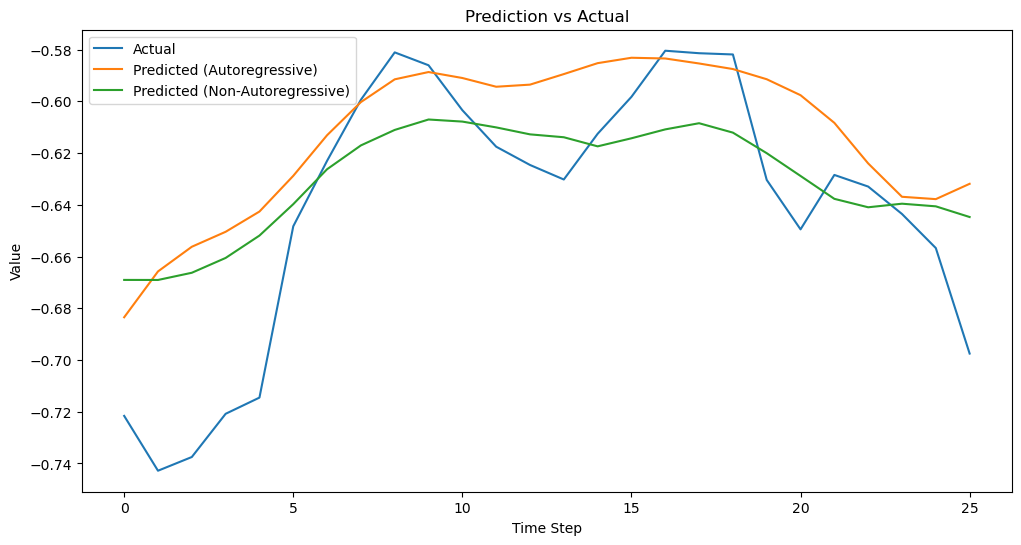

In [24]:
transformer.eval()  # Set the model to evaluation mode

# Convert the test sequences to a PyTorch tensor and move it to the device
test_src_data = torch.tensor(test_sequences).float().to(device)
test_tgt_data = torch.tensor(test_labels).float().to(device)

autoregressive_pred = autoregressive_prediction(transformer, test_src_data.clone(), SEQUENCE_LENGTH)
non_autoregressive_pred = non_autoregressive_prediction(transformer, test_src_data.clone())

# denorm_auto_pred = denormalize_data(autoregressive_pred, stats)
# denorm_non_auto_pred = denormalize_data(non_autoregressive_pred, stats)

# denormalized_actual = denormalize_data(test_tgt_data[:, :, :].cpu().numpy(), stats)

# denormalized_last_src = test_src_data[:, -1:, :].cpu().numpy().copy() # Use copy
# for i, ticker in enumerate(tickers):
#     for j, col in enumerate(df.columns):
#         if col.startswith(ticker):
#             mean = stats[f"{col}_mean"]
#             std = stats[f"{col}_std"]
#             denormalized_last_src[:, :, j] = denormalized_last_src[:, :, j] * std + mean

def plot_data(pred_auto, pred_nonauto, actual, col):    
    for i in range(6):
        plt.figure(figsize=(12, 6))

        # actual_plot_data = np.concatenate((denormalized_last_src[i, :, col], actual[i, :, col]), axis=0)
        # predicted_auto = np.concatenate((denormalized_last_src[i, :, col], pred_auto[i, :, col]), axis=0)
        # predicted_nonauto = np.concatenate((denormalized_last_src[i, :, col], pred_nonauto[i, :, col]), axis=0)

        predicted_auto = pred_auto[i, :, col]
        predicted_nonauto = pred_nonauto[i, :, col]
        actual_plot_data = actual[i, :, col]

        mse_auto = MSE(predicted_auto, actual_plot_data)
        mse_nonauto = MSE(predicted_nonauto, actual_plot_data)
        print(f"MSE (Autoregressive): {mse_auto}")
        print(f"MSE (Non-Autoregressive): {mse_nonauto}")

        mae_auto = MAE(predicted_auto, actual_plot_data)
        mae_nonauto = MAE(predicted_nonauto, actual_plot_data)
        print(f"MAE (Autoregressive): {mae_auto}")
        print(f"MAE (Non-Autoregressive): {mae_nonauto}")
        
        x_values = np.arange(SEQUENCE_LENGTH)

        plt.plot(x_values, actual_plot_data, label='Actual')
        plt.plot(x_values, predicted_auto, label='Predicted (Autoregressive)')
        plt.plot(x_values, predicted_nonauto, label='Predicted (Non-Autoregressive)')

        plt.title(f'Prediction vs Actual')
        plt.xlabel('Time Step')
        plt.ylabel('Value')
        plt.legend()
        plt.show()

# plot_data(denorm_auto_pred.copy(), denorm_non_auto_pred.copy(), denormalized_actual.copy(), 3)
plot_data(autoregressive_pred, non_autoregressive_pred, test_labels, 3)

In [19]:
from datetime import datetime, timedelta

# end_date = datetime.now().date()
# start_date = end_date - timedelta(days=7)

# data = yf.download("AAPL", start=start_date, end=end_date)
# data.drop(columns=['Volume'], inplace=True)

# start_vec = data.iloc[0]
# start_vec = torch.tensor(start_vec.values).float().to(device).unsqueeze(0)

print(denorm_auto_pred.shape)
print(denormalized_actual.shape)
print()

print(test_sequences.shape)
print()

print(denormalized_last_src.shape)
print(len(denormalized_last_src))

(505, 26, 132)
(505, 26, 132)

(505, 26, 132)

(505, 1, 132)
505
